In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('default')

## Problem Set 1 (Air Quality Data)

**Dataset link:** https://tinyurl.com/2fe6vz4u

**Note:** Add labels to every axis, a proper title, and legends where necessary.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Air Quality Data
df_air = pd.read_csv('https://tinyurl.com/2fe6vz4u')
df_air.head()

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018
3,3,4,India,Varanasi,2016,146,>75%,260,NaN,2018
4,4,5,India,Patna,2016,144,>75%,266,NaN,2018


### **Problem-1:**
Draw a line plot of which, the x-axis is the "Year" and the y-axis is sum of "PM2.5" of two countries Iran and China.

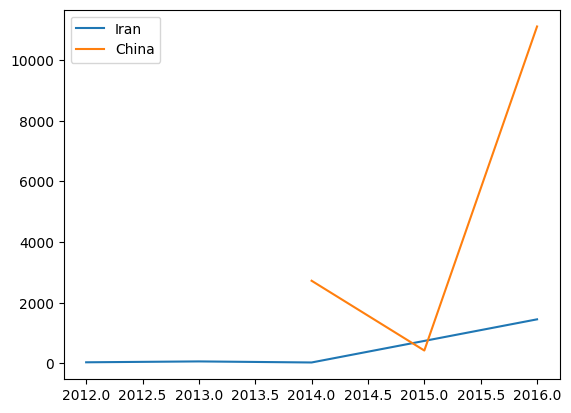

In [37]:
# Your code for Problem 1 here

iran = df_air.query('Country == "Iran"').groupby('Year')['PM2.5'].sum()
china = df_air.query('Country == "China"').groupby('Year')['PM2.5'].sum()

plt.plot(iran.index,iran.values,label="Iran")
plt.plot(china.index,china.values,label="China")

plt.legend()
plt.show()

### **Problem-2:**
Draw a histogram of the column "PM10" of which the y-axis represents the probability.

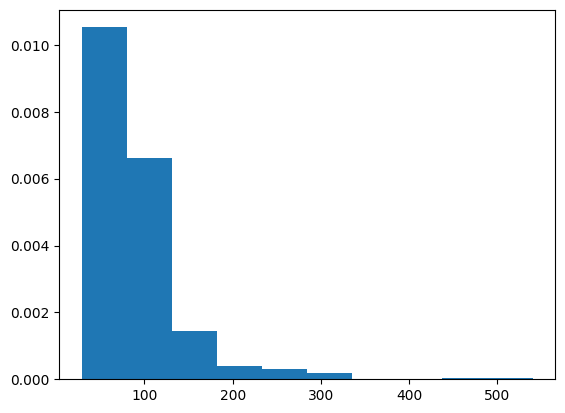

In [41]:
plt.hist(df_air['PM10'],density=True)
plt.show()

### **Problem-3:**
Draw a scatter plot where x-axis represents "PM2.5" and y-axis represents "PM10" for two countries Poland and Chile.

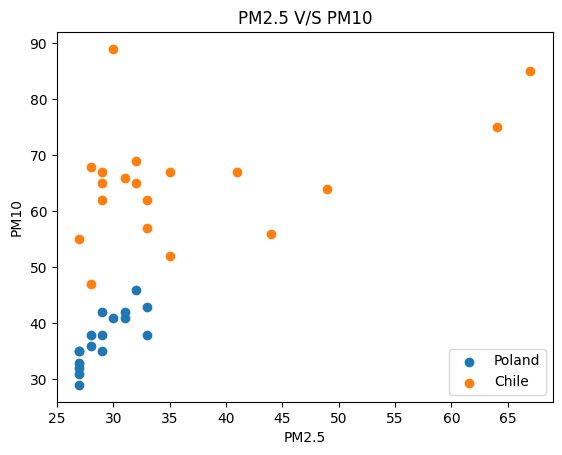

In [48]:
poland = df_air.query('Country == "Poland"')[['PM2.5','PM10']]
chile = df_air.query('Country == "Chile"')[['PM2.5','PM10']]

poland

plt.scatter(poland['PM2.5'],poland['PM10'],label = "Poland")
plt.scatter(chile['PM2.5'],chile['PM10'], label = "Chile")
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.title('PM2.5 V/S PM10')
plt.legend()
plt.show()




### **Problem-4:**
Draw a pie chart of top 5 most frequent countries.

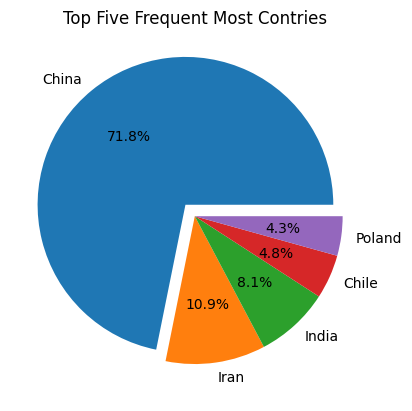

In [62]:
# Your code for Problem 4 here
top_five_countries = df_air['Country'].value_counts().head(5)
plt.pie(top_five_countries,labels=top_five_countries.index,explode=[0.1,0,0,0,0],autopct='%0.1f%%')
plt.title('Top Five Frequent Most Contries')
plt.show()


### **Problem-5:**
Draw a bar chart which represents the counts of top 5 most frequent countries.

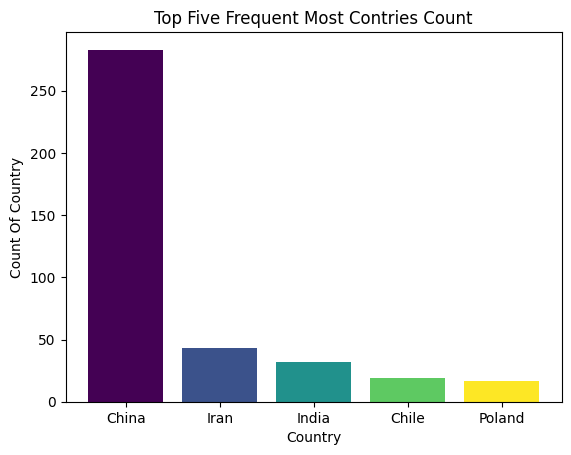

In [74]:
# Your code for Problem 5 here
top_five_countries

colors = plt.cm.viridis(np.linspace(0,1,len(top_five_countries)))

plt.bar(top_five_countries.index,top_five_countries.values,color=colors)
plt.xlabel('Country')
plt.ylabel('Count Of Country')
plt.title('Top Five Frequent Most Contries Count')
plt.show()

## Problem Set 2 (Company Sales Data)

**Dataset link:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv

In [75]:
# Load Sales Data
df_sales = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv')
df_sales.head()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600


### **Problem-6:**
Show a line plot of Total Profit for each month with: Dotted Line, Blue Color, Legend at top left, and Circle Marker.

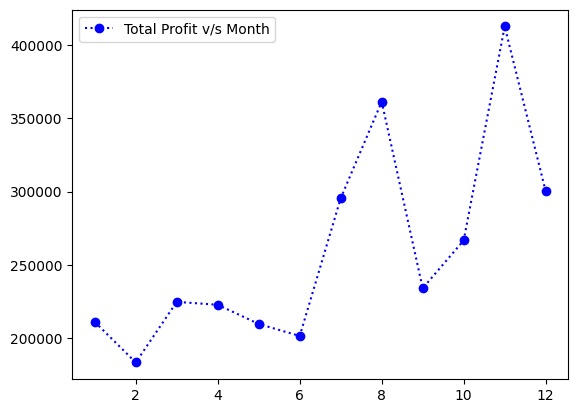

In [98]:
# Your code for Problem 6 here

month_wise_profit = df_sales.groupby('month_number').agg({
    'total_profit' : 'sum'
})


plot_two = plt.plot(month_wise_profit.index,month_wise_profit['total_profit'],marker='o',color='blue',linestyle = ':',label='Total Profit v/s Month')
plt.legend(loc='upper left')


### **Problem-7:**
Show sales of each product in March month as a pie chart. Explode ToothPaste with shadow and show percentages.

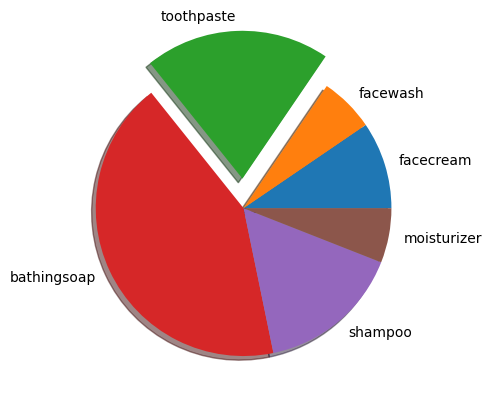

In [127]:
# Your code for Problem 7 here

labels = df_sales[df_sales['month_number'] == 3].iloc[:,1:7].stack().index.get_level_values(1)
values = df_sales[df_sales['month_number'] == 3].iloc[:,1:7].stack().values
labels
plot_three = plt.pie(values,labels=labels,explode=[0,0,0.2,0,0,0],shadow=True)


### **Problem-8:**
Multiline Plot of all products sales with different styles and legend at top right.

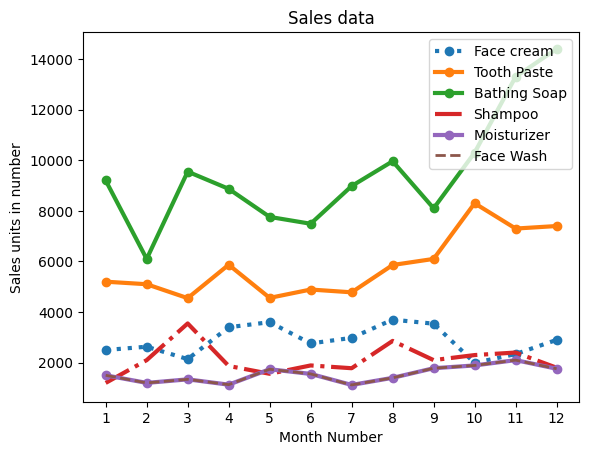

In [139]:
# code here
monthList  = df_sales['month_number'].tolist()

plt.plot(monthList, df_sales['facecream'],   label = 'Face cream', linestyle='dotted', marker='o', linewidth=3)
plt.plot(monthList, df_sales['toothpaste'], label = 'Tooth Paste', marker='o', linewidth=3)
plt.plot(monthList, df_sales['bathingsoap'], label = 'Bathing Soap', marker='o', linewidth=3)
plt.plot(monthList, df_sales['shampoo'], label = 'Shampoo', linestyle='dashdot', linewidth=3)
plt.plot(monthList, df_sales['moisturizer'], label = 'Moisturizer', marker='o', linewidth=3)
plt.plot(monthList, df_sales['facewash'],   label = 'Face Wash',  linestyle='dashed', linewidth=2)


plt.xlabel('Month Number')
plt.ylabel('Sales units in number')
plt.legend(loc='upper right')
plt.xticks(monthList)
plt.title('Sales data')
plt.show()

### **Problem-9:**
Show Quarter wise Sales data for all products as a multi Bar chart.

/tmp/ipykernel_1391/920258809.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quarter_sales = df_sales.groupby('Quarter')[['facecream','facewash','toothpaste',


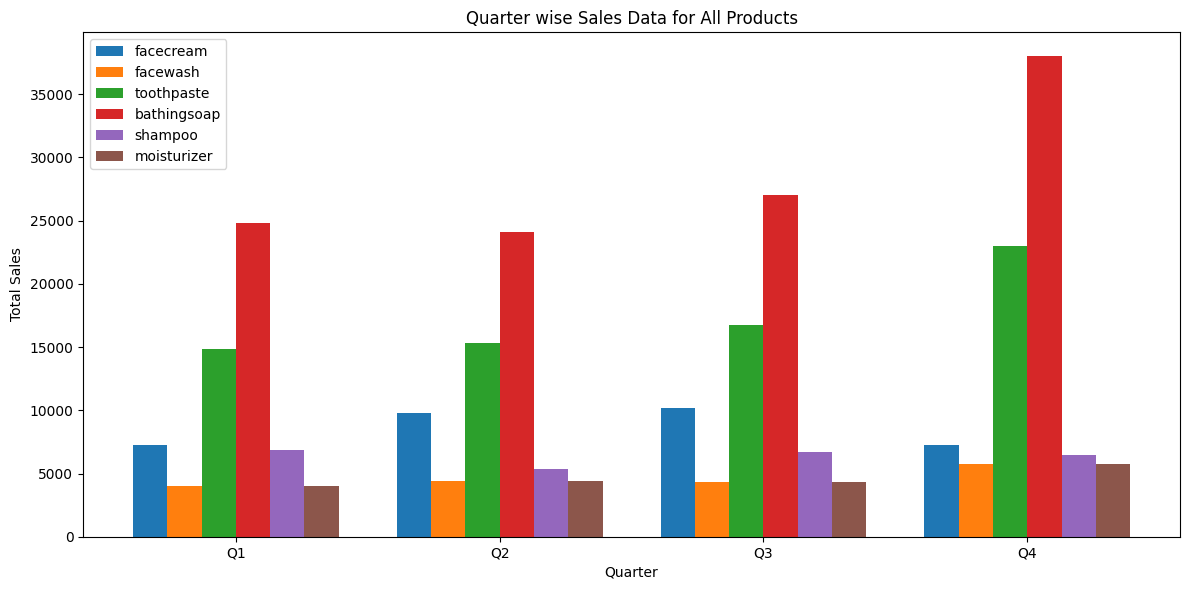

In [147]:
# Your code for Problem 9 here

df_sales['Quarter'] = pd.cut(df_sales['month_number'],
                              bins=[0,3,6,9,12],
                              labels=['Q1','Q2','Q3','Q4'])

quarter_sales = df_sales.groupby('Quarter')[['facecream','facewash','toothpaste',
                                              'bathingsoap','shampoo','moisturizer']].sum()
products = quarter_sales.columns
quarters = quarter_sales.index
x = np.arange(len(quarters))      # positions for quarters
width = 0.13                      # width of each bar

plt.figure(figsize=(12,6))

for i, product in enumerate(products):
    plt.bar(x + i*width, quarter_sales[product], width=width, label=product)

plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.title('Quarter wise Sales Data for All Products')
plt.xticks(x + width*(len(products)-1)/2, quarters)
plt.legend()
plt.tight_layout()
plt.show()